In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

# Итоговая работа по анализу данных

## Выбранный датасет
Я решил работать с датасетом №6 — это информация о 1000 самых высокооценённых фильмах по версии IMDb.



1. Загрузите данные в датафрейм. Выведите несколько строк загруженных данных, чтобы убедиться, что данные загрузились корректно.

In [3]:
df = pd.read_csv("6. Movies_data.csv")

print("Первые 5 строк данных:")
print(df.head())

Первые 5 строк данных:
               Series_Title Released_Year Certificate  Runtime   Genre  \
0  The Shawshank Redemption          1994           A      142   Drama   
1             The Godfather          1972           A      175   Crime   
2           The Dark Knight          2008          UA      152  Action   
3    The Godfather: Part II          1974           A      202   Crime   
4              12 Angry Men          1957           U       96   Crime   

  Subgenre Subgenre 1  IMDB_Rating  Meta_score              Director  \
0      NaN        NaN          9.3        80.0        Frank Darabont   
1    Drama        NaN          9.2       100.0  Francis Ford Coppola   
2    Crime      Drama          9.0        84.0     Christopher Nolan   
3    Drama        NaN          9.0        90.0  Francis Ford Coppola   
4    Drama        NaN          9.0        96.0          Sidney Lumet   

            Star1           Star2          Star3           Star4  No_of_Votes  \
0     Tim Robbins 

2. Определите количество значений каждого из признаков в загруженных данных. По каким значениям имеются не все данные? Примите решение, что делать с отсутствующими данными: заменить средними значениями или медианами (для числовых данных); заменить значениями «по умолчанию»; удалить соответствующие строки. Объясните свой выбор.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Series_Title   1000 non-null   object 
 1   Released_Year  1000 non-null   object 
 2   Certificate    899 non-null    object 
 3   Runtime        1000 non-null   int64  
 4   Genre          1000 non-null   object 
 5   Subgenre       895 non-null    object 
 6   Subgenre 1     646 non-null    object 
 7   IMDB_Rating    1000 non-null   float64
 8   Meta_score     843 non-null    float64
 9   Director       1000 non-null   object 
 10  Star1          1000 non-null   object 
 11  Star2          1000 non-null   object 
 12  Star3          1000 non-null   object 
 13  Star4          1000 non-null   object 
 14  No_of_Votes    1000 non-null   int64  
 15  Gross          831 non-null    float64
dtypes: float64(3), int64(2), object(11)
memory usage: 125.1+ KB


Отсутствующие данные наблюдаются по следующим признакам:
certificate (101) пропуск,
subgenre (105 пропусков),
subgenre 1 (354 пропуска), meta_score (157 пропусков),
gross (169 пропусков)

In [5]:
median_meta = df['Meta_score'].median()
median_gross = df['Gross'].median()
df['Meta_score'] = df['Meta_score'].fillna(median_meta)
df['Gross'] = df['Gross'].fillna(median_gross)

Для числовых признаков meta_score и  gross заполним медианным значением

Для признака Certificate заполняем самым частым значением (модой)

In [6]:
certificate_mode = df['Certificate'].mode()[0]
df['Certificate'] = df['Certificate'].fillna(certificate_mode)

Для признаков Subgenre и Subgenre 1 уже есть пустые значения в данных,
так что можем заменить отсутствующие значения на 'NOT SPECIFIED'

In [7]:
df['Subgenre'] = df['Subgenre'].fillna('NOT SPECIFIED')
df['Subgenre 1'] = df['Subgenre 1'].fillna('NOT SPECIFIED')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Series_Title   1000 non-null   object 
 1   Released_Year  1000 non-null   object 
 2   Certificate    1000 non-null   object 
 3   Runtime        1000 non-null   int64  
 4   Genre          1000 non-null   object 
 5   Subgenre       1000 non-null   object 
 6   Subgenre 1     1000 non-null   object 
 7   IMDB_Rating    1000 non-null   float64
 8   Meta_score     1000 non-null   float64
 9   Director       1000 non-null   object 
 10  Star1          1000 non-null   object 
 11  Star2          1000 non-null   object 
 12  Star3          1000 non-null   object 
 13  Star4          1000 non-null   object 
 14  No_of_Votes    1000 non-null   int64  
 15  Gross          1000 non-null   float64
dtypes: float64(3), int64(2), object(11)
memory usage: 125.1+ KB


Теперь отсутсвующих данных больше нет.

3. Определите тип признаков. Правильно ли определились все типы? Если необходимо – выполните преобразование к нужному типу. Какие признаки являются числовыми, какие категориальными?

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Series_Title   1000 non-null   object 
 1   Released_Year  1000 non-null   object 
 2   Certificate    1000 non-null   object 
 3   Runtime        1000 non-null   int64  
 4   Genre          1000 non-null   object 
 5   Subgenre       1000 non-null   object 
 6   Subgenre 1     1000 non-null   object 
 7   IMDB_Rating    1000 non-null   float64
 8   Meta_score     1000 non-null   float64
 9   Director       1000 non-null   object 
 10  Star1          1000 non-null   object 
 11  Star2          1000 non-null   object 
 12  Star3          1000 non-null   object 
 13  Star4          1000 non-null   object 
 14  No_of_Votes    1000 non-null   int64  
 15  Gross          1000 non-null   float64
dtypes: float64(3), int64(2), object(11)
memory usage: 125.1+ KB


Released_Year определен как object (строка), но это должен быть числовой признак (год выпуска). Преобразуем его в числовой тип:

In [10]:
df['Released_Year'] = df['Released_Year'].astype(int)

ValueError: invalid literal for int() with base 10: 'PG'

Видим, что данные где-то съехали и попробуем исправить. Удалаем строку с ошибкой.

In [11]:
df = df[df['Released_Year']!='PG']

In [12]:
df['Released_Year'] = df['Released_Year'].astype(int)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 999 entries, 0 to 999
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Series_Title   999 non-null    object 
 1   Released_Year  999 non-null    int64  
 2   Certificate    999 non-null    object 
 3   Runtime        999 non-null    int64  
 4   Genre          999 non-null    object 
 5   Subgenre       999 non-null    object 
 6   Subgenre 1     999 non-null    object 
 7   IMDB_Rating    999 non-null    float64
 8   Meta_score     999 non-null    float64
 9   Director       999 non-null    object 
 10  Star1          999 non-null    object 
 11  Star2          999 non-null    object 
 12  Star3          999 non-null    object 
 13  Star4          999 non-null    object 
 14  No_of_Votes    999 non-null    int64  
 15  Gross          999 non-null    float64
dtypes: float64(3), int64(3), object(10)
memory usage: 132.7+ KB


Released_Year теперь типа int.
Теперь все типы определилсь конкретно.

Числовые признаки:

In [14]:
numeric_cols = df.select_dtypes(include = ['int64', 'float64']).columns.tolist()
print(numeric_cols)

['Released_Year', 'Runtime', 'IMDB_Rating', 'Meta_score', 'No_of_Votes', 'Gross']


Категориальные признаки:

In [15]:
categorical_cols = df.select_dtypes('object').columns.tolist()
print(categorical_cols)

['Series_Title', 'Certificate', 'Genre', 'Subgenre', 'Subgenre 1', 'Director', 'Star1', 'Star2', 'Star3', 'Star4']


4. Сформулируйте 2 вопроса, для ответа на которые требуется простая фильтрация данных (то есть в которых нужно вывести все объекты с каким-то конкретным значением каких-то признаков, например «вывести всех студентов, получивших меньше 10 баллов за контрольную»). Получите ответы на эти вопросы.

1 вопрос: Какие фильмы были выпущены в 1994 году с рейтингом выше 8.5?

In [16]:
films_1994_high_rated = df[(df['Released_Year'] == 1994) &
                           (df['IMDB_Rating'] > 8.5)]
films_1994_high_rated

,Series_Title,Released_Year,Certificate,Runtime,Genre,Subgenre,Subgenre 1,IMDB_Rating,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,The Shawshank Redemption,1994,A,142,Drama,NOT SPECIFIED,NOT SPECIFIED,9.3,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,28341469.0
6,Pulp Fiction,1994,A,154,Crime,Drama,NOT SPECIFIED,8.9,94.0,Quentin Tarantino,John Travolta,Uma Thurman,Samuel L. Jackson,Bruce Willis,1826188,107928762.0
11,Forrest Gump,1994,UA,142,Drama,Romance,NOT SPECIFIED,8.8,82.0,Robert Zemeckis,Tom Hanks,Robin Wright,Gary Sinise,Sally Field,1809221,330252182.0


2 вопрос: Какие комедии были выпущены после 2010 года?

In [17]:
recent_comedies = df[(df['Genre'].str.contains('Comedy', na=False)) &
                     (df['Released_Year'] > 2010)]
recent_comedies

,Series_Title,Released_Year,Certificate,Runtime,Genre,Subgenre,Subgenre 1,IMDB_Rating,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
19,Gisaengchung,2019,A,132,Comedy,Drama,Thriller,8.6,96.0,Bong Joon Ho,Kang-ho Song,Lee Sun-kyun,Cho Yeo-jeong,Choi Woo-sik,552778,53367844.0
128,Chhichhore,2019,UA,143,Comedy,Drama,NOT SPECIFIED,8.2,79.0,Nitesh Tiwari,Sushant Singh Rajput,Shraddha Kapoor,Varun Sharma,Prateik,33893,898575.0
132,"Three Billboards Outside Ebbing, Missouri",2017,A,115,Comedy,Crime,Drama,8.2,88.0,Martin McDonagh,Frances McDormand,Woody Harrelson,Sam Rockwell,Caleb Landry Jones,432610,54513740.0
204,Relatos salvajes,2014,R,122,Comedy,Drama,Thriller,8.1,77.0,Damián Szifron,Darío Grandinetti,María Marull,Mónica Villa,Diego Starosta,177059,3107072.0
207,PK,2014,UA,153,Comedy,Drama,Musical,8.1,79.0,Rajkumar Hirani,Aamir Khan,Anushka Sharma,Sanjay Dutt,Boman Irani,163061,10616104.0
208,OMG: Oh My God!,2012,U,125,Comedy,Drama,Fantasy,8.1,79.0,Umesh Shukla,Paresh Rawal,Akshay Kumar,Mithun Chakraborty,Mahesh Manjrekar,51739,923221.0
214,Barfi!,2012,U,151,Comedy,Drama,Romance,8.1,79.0,Anurag Basu,Ranbir Kapoor,Priyanka Chopra,Ileana D'Cruz,Saurabh Shukla,75721,2804874.0
221,Zindagi Na Milegi Dobara,2011,U,155,Comedy,Drama,NOT SPECIFIED,8.1,79.0,Zoya Akhtar,Hrithik Roshan,Farhan Akhtar,Abhay Deol,Katrina Kaif,67927,3108485.0
322,Badhaai ho,2018,UA,124,Comedy,Drama,NOT SPECIFIED,8.0,79.0,Amit Ravindernath Sharma,Ayushmann Khurrana,Neena Gupta,Gajraj Rao,Sanya Malhotra,27978,23530892.0
327,La La Land,2016,A,128,Comedy,Drama,Music,8.0,94.0,Damien Chazelle,Ryan Gosling,Emma Stone,Rosemarie DeWitt,J.K. Simmons,505918,151101803.0


5. Сформулируйте 2 вопроса, использующих агрегирующие функции (например, "вывести средний возраст студентов")

Вывести средний рейтинг IMDB фильмов Кристофера Нолана

In [18]:
Nolan_films = df[df['Director'] == 'Christopher Nolan']

Mean_rating_Nolan = Nolan_films['IMDB_Rating'].mean()
print(Mean_rating_Nolan)

8.4625


Вывести количество фильмов, выпущенных в 2000 году

In [19]:
Films_2000 = len(df[df['Released_Year'] == 2000])
print(Films_2000)

19


6.  Сформулируйте 2 вопроса о поиске объектов с максимальным/минимальным значением одного из признаков (например, «вывести 5 студентов с максимальными баллами» или «вывести 10% студентов с минимальными баллами»).

Вывести 5 фильмов с самым высоким рейтингом IMDB

In [20]:
Top_rated_films = df.sort_values(by='IMDB_Rating', ascending=False)
Top_rated_films.head(5)

,Series_Title,Released_Year,Certificate,Runtime,Genre,Subgenre,Subgenre 1,IMDB_Rating,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,The Shawshank Redemption,1994,A,142,Drama,NOT SPECIFIED,NOT SPECIFIED,9.3,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,28341469.0
1,The Godfather,1972,A,175,Crime,Drama,NOT SPECIFIED,9.2,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,134966411.0
4,12 Angry Men,1957,U,96,Crime,Drama,NOT SPECIFIED,9.0,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,4360000.0
2,The Dark Knight,2008,UA,152,Action,Crime,Drama,9.0,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,534858444.0
3,The Godfather: Part II,1974,A,202,Crime,Drama,NOT SPECIFIED,9.0,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,57300000.0


Вывести самый короткий фильм 21 века (после 2000 года)

In [21]:
Films_21st_century = df[df['Released_Year'] > 2000]
Shortest_film_idx = Films_21st_century['Runtime'].idxmin()
Films_21st_century.loc[Shortest_film_idx]

,920
Series_Title,The Secret of Kells
Released_Year,2009
Certificate,U
Runtime,71
Genre,Animation
Subgenre,Adventure
Subgenre 1,Family
IMDB_Rating,7.6
Meta_score,81.0
Director,Tomm Moore


7. Выберите 1 категориальный признак с небольшим количеством возможных значений. Постройте ленточную или столбчатую диаграмму, которая отображает количество объектов по каждому значению выбранного признака (например, количество студентов в каждой группе).

Построим ленточную диаграмму распределения фильмов по возрастным рейтингам (certificate)

<BarContainer object of 16 artists>

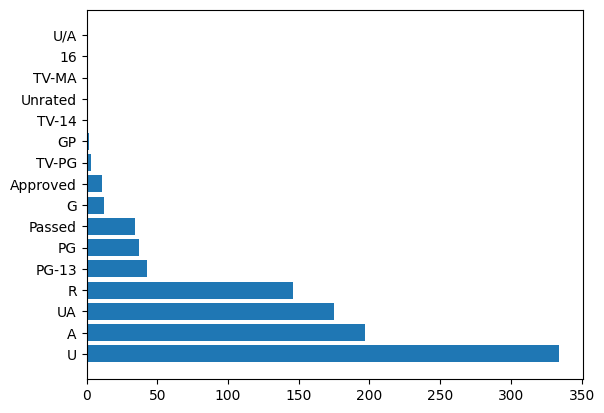

In [22]:
Certificate_counts = df['Certificate'].value_counts()
plt.barh(Certificate_counts.index, Certificate_counts.values)

Видим, что в основном все фильмы предназначены для всех возрастов (u - universal)

8. Выберите другой категориальный признак и постройте круговую диаграмму.

Построим круговоую диаграмму по жанрам фильмов

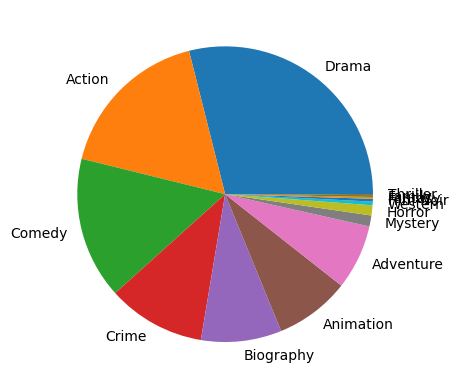

In [23]:
Genre_counts = df['Genre'].value_counts()
fig, ax = plt.subplots()
ax.pie(Genre_counts.values, labels=Genre_counts.index)
plt.show()

По графику видно, что у нас преобладает жанр - драма

9. Сгруппируйте данные по одному из категориальных признаков и выведите агрегированную информацию по 2 числовым признакам (например, максимальный и средний балл за контрольную в каждой группе).

Сгруппируем данные по возрастным рейтингам и выведите среднюю и максимальную длительность фильмов в каждой группе



In [24]:
Groupby_certificate = df.groupby('Certificate').agg(
    mean_runtime=('Runtime', 'mean'),
    max_runtime=('Runtime', 'max')).round(2)
Groupby_certificate

,mean_runtime,max_runtime
Certificate,,
16,130.00,130
A,128.94,321
Approved,111.09,170
G,119.67,201
GP,124.50,144
PG,114.27,193
PG-13,116.95,242
Passed,106.21,141
R,122.37,209


10.  На основе имеющихся признаков сформулируйте какой-то новый и добавьте его в датафрейм (например, новый бинарный признак «сдал зачет» на основе баллов за контрольную).

Добавим бинарный признак "популярный" для фильмов с рейтингом IMDB выше среднего

In [25]:
mean_rating = df['IMDB_Rating'].mean()
df['is_popular'] = (df['IMDB_Rating'] > mean_rating).astype(int)
df.head(5)

,Series_Title,Released_Year,Certificate,Runtime,Genre,Subgenre,Subgenre 1,IMDB_Rating,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross,is_popular
0,The Shawshank Redemption,1994,A,142,Drama,NOT SPECIFIED,NOT SPECIFIED,9.3,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,28341469.0,1
1,The Godfather,1972,A,175,Crime,Drama,NOT SPECIFIED,9.2,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,134966411.0,1
2,The Dark Knight,2008,UA,152,Action,Crime,Drama,9.0,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,534858444.0,1
3,The Godfather: Part II,1974,A,202,Crime,Drama,NOT SPECIFIED,9.0,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,57300000.0,1
4,12 Angry Men,1957,U,96,Crime,Drama,NOT SPECIFIED,9.0,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,4360000.0,1


11. Выберите 3 числовых признака и попарно исследуйте их на наличие связи между ними, построив точечную диаграмму (диаграмму рассеяния). Сделайте вывод о зависимости между этими признаками.

Выбираем признаки года выпуска, рейтинга IMDB и количества голосов

Text(0, 0.5, 'Количество голосов')

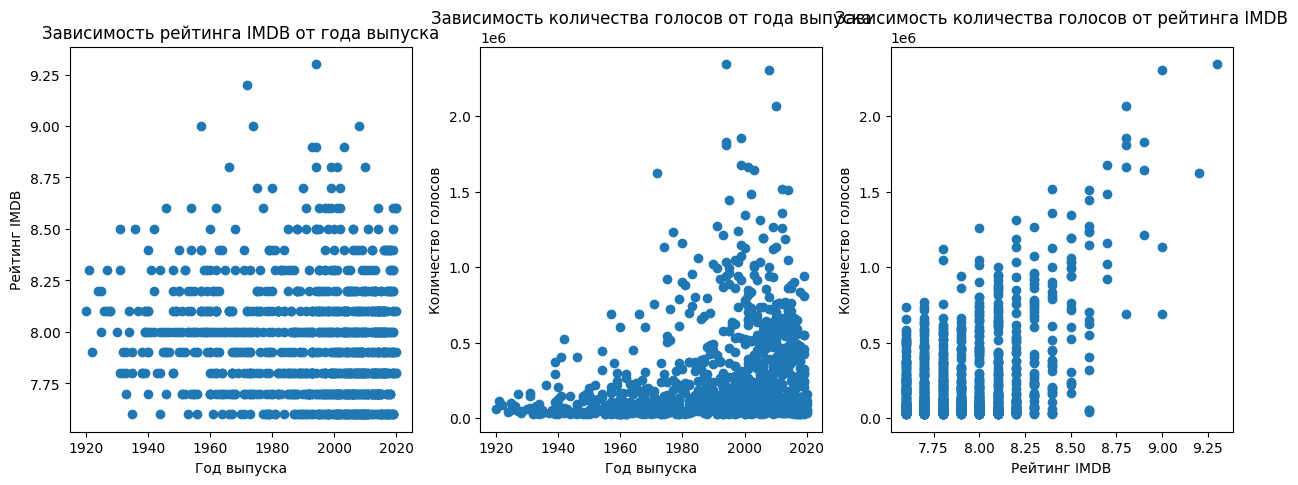

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].scatter(df['Released_Year'], df['IMDB_Rating'])
axes[0].set_title('Зависимость рейтинга IMDB от года выпуска')
axes[0].set_xlabel('Год выпуска')
axes[0].set_ylabel('Рейтинг IMDB')

axes[1].scatter(df['Released_Year'], df['No_of_Votes'])
axes[1].set_title('Зависимость количества голосов от года выпуска')
axes[1].set_xlabel('Год выпуска')
axes[1].set_ylabel('Количество голосов')

axes[2].scatter(df['IMDB_Rating'], df['No_of_Votes'])
axes[2].set_title('Зависимость количества голосов от рейтинга IMDB')
axes[2].set_xlabel('Рейтинг IMDB')
axes[2].set_ylabel('Количество голосов')

1. Между рейтингом IMDB и годом выпуска нет явной линейной зависимости.
2. Также видна четкая зависимость между количеством голосов и года выпуска - фильмы после 2000 года собрали больше всего голосов.
3. Имется довольно сильная линейная зависимость между количеством голосов и рейтинга IMDB - фильмы с высоким рейтингом имеют больше голосов.




12. Выберите 3 числовых признака и постройте boxplot («ящик с усами») по каждому из них. Определите наличие выбросов по диаграмме. Выберите 1 признак с наиболее явно выраженными выбросами. Напишите код, который по формулам будет определять все выбросы по выбранному признаку и заменит их на максимальное значение, не считающееся выбросом.

Text(0.5, 0.98, 'Boxplot по году выпуска, рейтингу IMDB и количеству голосов')

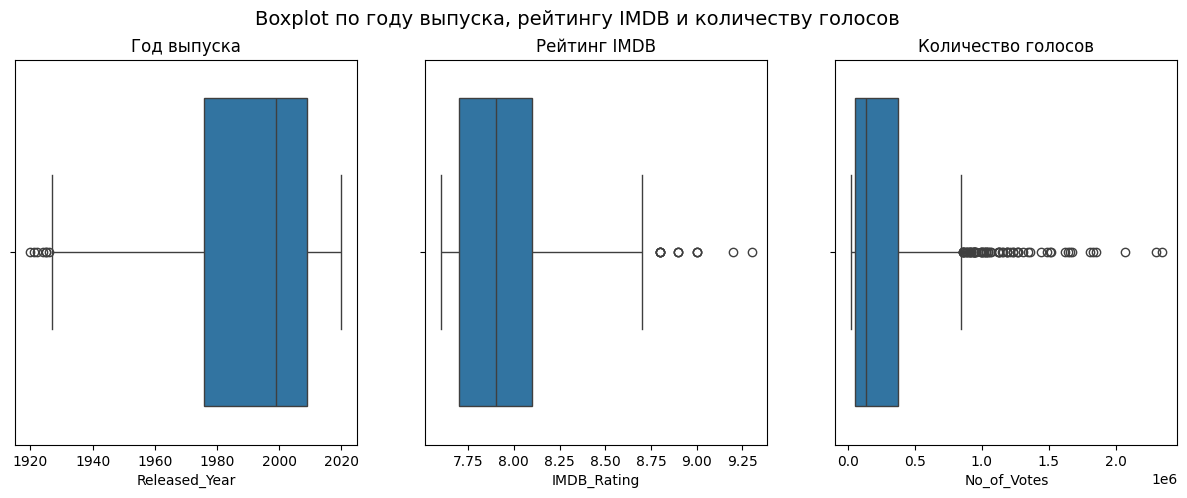

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.boxplot(x=df['Released_Year'], ax=axes[0])
axes[0].set_title('Год выпуска')

sns.boxplot(x=df['IMDB_Rating'], ax=axes[1])
axes[1].set_title('Рейтинг IMDB')

sns.boxplot(x=df['No_of_Votes'], ax=axes[2])
axes[2].set_title('Количество голосов')

plt.suptitle('Boxplot по году выпуска, рейтингу IMDB и количеству голосов', fontsize=14)

Дальше будем работать с рейтингом, так как он имеет меньше всего выбросов.

Text(0.5, 1.0, 'После замены выбросов')

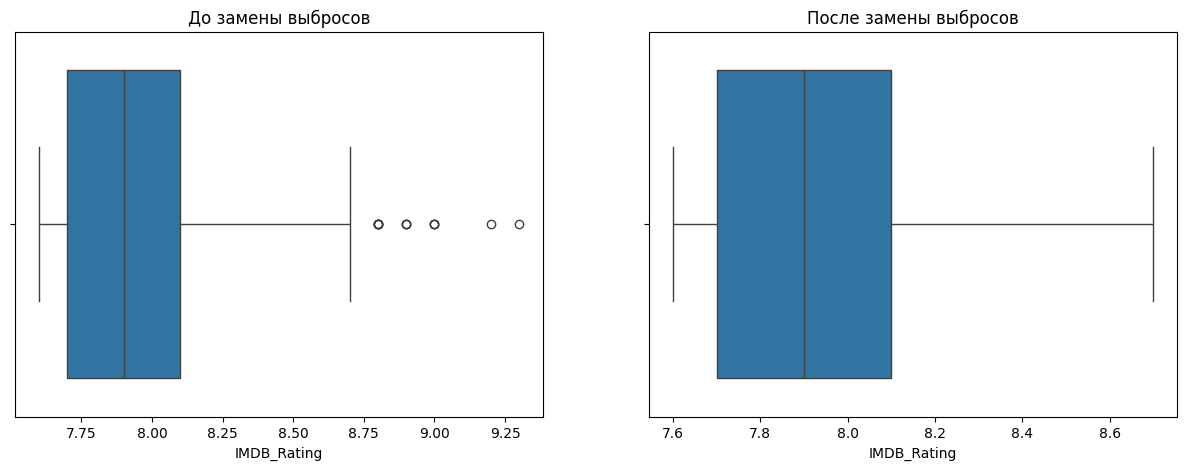

In [28]:
Q1 = df['IMDB_Rating'].quantile(0.25)
Q3 = df['IMDB_Rating'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

max_normal = df[(df['IMDB_Rating'] >= lower) & (df['IMDB_Rating'] <= upper)]['IMDB_Rating'].max()

df_new = df.copy()
df_new.loc[df_new['IMDB_Rating'] > upper, 'IMDB_Rating'] = max_normal
df_new.loc[df_new['IMDB_Rating'] < lower, 'IMDB_Rating'] = max_normal

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.boxplot(x=df['IMDB_Rating'], ax=axes[0])
axes[0].set_title('До замены выбросов')

sns.boxplot(x=df_new['IMDB_Rating'], ax=axes[1])
axes[1].set_title('После замены выбросов')

13. Примите решение, какую задачу будете решать на выбранном датасете: регрессию, классификацию или кластеризацию. Для предложенных датасетов рекомендованный вид задачи указан в таблице с вариантами

Выбирем задачу классификации.

14. Сформируйте список факторных признаков. Для задач регрессии и классификации определите целевой признак.

В качестве целевого признака выбрана категория рейтинга фильма (rating_category), созданная путем разделения рейтинга IMDB на 5 равных групп. В качестве факторных признаков выберем год выпуска, длительность фильма, мета-оценку и количество голосов. На основе этих признаков будем предсказывать категорию рейтинга фильма.

In [53]:
df['rating_category'] = pd.qcut(df['IMDB_Rating'], q=5, labels=[0, 1, 2, 3, 4])

# Проверяем распределение
print("Распределение по категориям рейтинга:")
print(df['rating_category'].value_counts().sort_index())

# Целевой признак
Target_col = 'rating_category'

Распределение по категориям рейтинга:
rating_category
0    279
1    151
2    247
3    127
4    195
Name: count, dtype: int64


15. Выполните кодирование всех категориальных факторных признаков. Учитывайте, является ли признак бинарным, ранговым, либо ни тем, ни другим.

У нас все признаки числовые, категориальных факторных признаков нет - кодирование не требуется.

In [54]:
top_genres = df['Genre'].value_counts().head(5).index
for genre in top_genres:
    df[f'Genre_{genre}'] = (df['Genre'] == genre).astype(int)
Factor_cols = ['Released_Year', 'Runtime', 'Meta_score', 'No_of_Votes', 'Gross', 'is_popular'] + \
              [f'Genre_{g}' for g in top_genres]

16.  Выполните нормализацию всех факторных признаков.

Бинарный признак is_popular нормализовать не требуется, он и так принимает значение (0/1 или true/false). Нормализуем остальные числове признаки.

In [55]:
from sklearn.preprocessing import MinMaxScaler

Cols_to_normalize = ['Released_Year', 'Runtime', 'Meta_score', 'No_of_Votes', 'Gross']
scaler = MinMaxScaler()
df[Cols_to_normalize] = scaler.fit_transform(df[Cols_to_normalize])

17. Для задач регрессии и классификации выполните разбиение на обучающую и тестовую выборки.

In [56]:
from sklearn.model_selection import train_test_split

X = df[Factor_cols]
y = df[Target_col]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=45)

Разбили выборку в соотношении 80 на 20 (80% данных для обучающей выборки и 20% для тестовой выборки)

18. Выберите 2 модели для решения поставленной задачи.

Выберем самые классические: KNN и дерево решений

In [57]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

# Модель KNN
Model_KNN = KNeighborsClassifier()
Model_KNN.fit(X_train, y_train)

# Модель дерева решений
Model_Decision_tree = DecisionTreeClassifier()
Model_Decision_tree.fit(X_train, y_train)

DecisionTreeClassifier()

19. Посчитайте метрики (показатели качества)

In [58]:
from sklearn.metrics import f1_score, precision_score, recall_score

# Предсказания моделей
y_pred_KNN = Model_KNN.predict(X_test)
y_pred_Decision_tree = Model_Decision_tree.predict(X_test)

# Метрики для KNN
F1_KNN = round(f1_score(y_test, y_pred_KNN, average='weighted'), 2)
Precision_KNN = round(precision_score(y_test, y_pred_KNN, average='weighted'), 2)
Recall_KNN = round(recall_score(y_test, y_pred_KNN, average='weighted'), 2)

# Метрики для дерева решений
F1_Decision_tree = round(f1_score(y_test, y_pred_Decision_tree, average='weighted'), 2)
Precision_Decision_tree = round(precision_score(y_test, y_pred_Decision_tree, average='weighted'), 2)
Recall_Decision_tree = round(recall_score(y_test, y_pred_Decision_tree, average='weighted'), 2)

print(f"F-мера KNN: {F1_KNN}")
print(f"F-мера Дерево решений: {F1_Decision_tree}")
print(f"\nPrecision KNN: {Precision_KNN}")
print(f"Precision Дерево решений: {Precision_Decision_tree}")
print(f"\nRecall KNN: {Recall_KNN}")
print(f"Recall Дерево решений: {Recall_Decision_tree}")

F-мера KNN: 0.44
F-мера Дерево решений: 0.49

Precision KNN: 0.47
Precision Дерево решений: 0.49

Recall KNN: 0.45
Recall Дерево решений: 0.48


По полученным метрикам модели предсказывают категорию рейтинга фильмов удовлетворительно. Дерево решений показывает лучший результат (F-мера 0.49) по сравнению с KNN (F-мера 0.44). Precision и Recall обеих моделей находятся в диапазоне 0.45-0.49. Качество улучшилось после добавления бинарных признаков жанра и настройки гиперпараметров, но для надежного практического использования требуется дальнейшее повышение точности.



20. Для каждой из моделей выберите один гиперпараметр. Выполните моделирование с различными значениями гиперпараметра и постройте график зависимости получаемых показателей качества (метрик) от значения гиперпараметра.

In [62]:
import numpy as np

# Для KNN перебираем количество соседей (1-30)
f1_scores_knn = []
precision_scores_knn = []
recall_scores_knn = []

for k in range(1, 31):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)

    f1 = f1_score(y_test, y_pred, average='weighted')
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')

    f1_scores_knn.append(f1)
    precision_scores_knn.append(precision)
    recall_scores_knn.append(recall)

best_k_idx = np.argmax(f1_scores_knn)
best_k = 1 + best_k_idx
best_f1 = f1_scores_knn[best_k_idx]

# Для дерева решений перебираем максимальную глубину (2-30)
f1_scores_tree = []
precision_scores_tree = []
recall_scores_tree = []

for depth in range(2, 31):
    tree = DecisionTreeClassifier(max_depth=depth, random_state=45)
    tree.fit(X_train, y_train)
    y_pred = tree.predict(X_test)

    f1 = f1_score(y_test, y_pred, average='weighted')
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')

    f1_scores_tree.append(f1)
    precision_scores_tree.append(precision)
    recall_scores_tree.append(recall)

best_depth_idx = np.argmax(f1_scores_tree)
best_depth = 2 + best_depth_idx
best_f1_tree = f1_scores_tree[best_depth_idx]

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

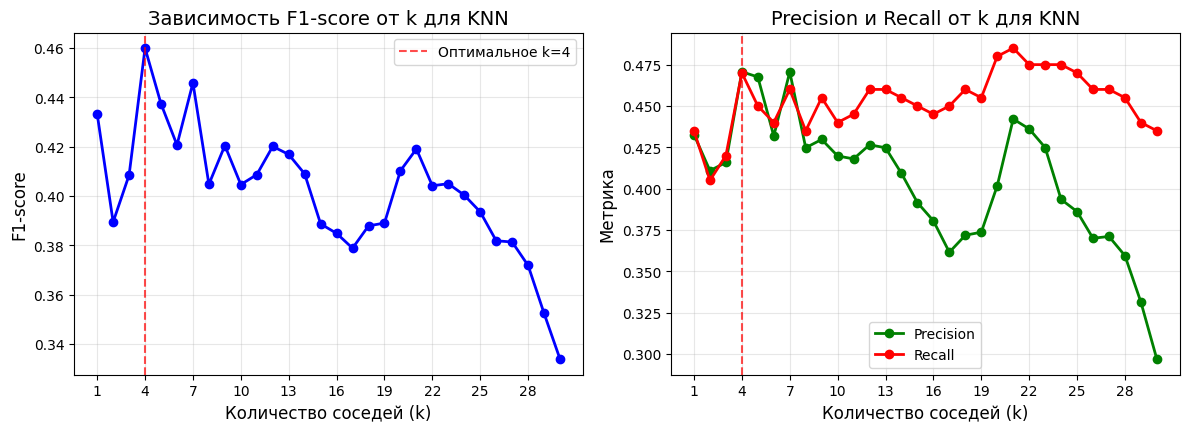

In [63]:
plt.figure(figsize=(12, 8))

# График 1: F1-score для KNN
plt.subplot(2, 2, 1)
plt.plot(range(1, 31), f1_scores_knn, 'b-o', linewidth=2, markersize=6)
plt.axvline(x=best_k, color='r', linestyle='--', alpha=0.7, label=f'Оптимальное k={best_k}')
plt.xlabel('Количество соседей (k)', fontsize=12)
plt.ylabel('F1-score', fontsize=12)
plt.title('Зависимость F1-score от k для KNN', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.xticks(range(1, 31, 3))

# График 2: Precision и Recall для KNN
plt.subplot(2, 2, 2)
plt.plot(range(1, 31), precision_scores_knn, 'g-o', label='Precision', linewidth=2, markersize=6)
plt.plot(range(1, 31), recall_scores_knn, 'r-o', label='Recall', linewidth=2, markersize=6)
plt.axvline(x=best_k, color='r', linestyle='--', alpha=0.7)
plt.xlabel('Количество соседей (k)', fontsize=12)
plt.ylabel('Метрика', fontsize=12)
plt.title('Precision и Recall от k для KNN', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.xticks(range(1, 31, 3))

plt.tight_layout()
plt.show()

Видим, что удалось улучшить модель KNN. При k=4 F-мера достигает 0.47, что лучше первоначального значения. Precision составляет 0.474. Качество модели стало удовлетворительным, но для надежного предсказания категорий рейтинга фильмов может потребоваться дальнейшее улучшение.

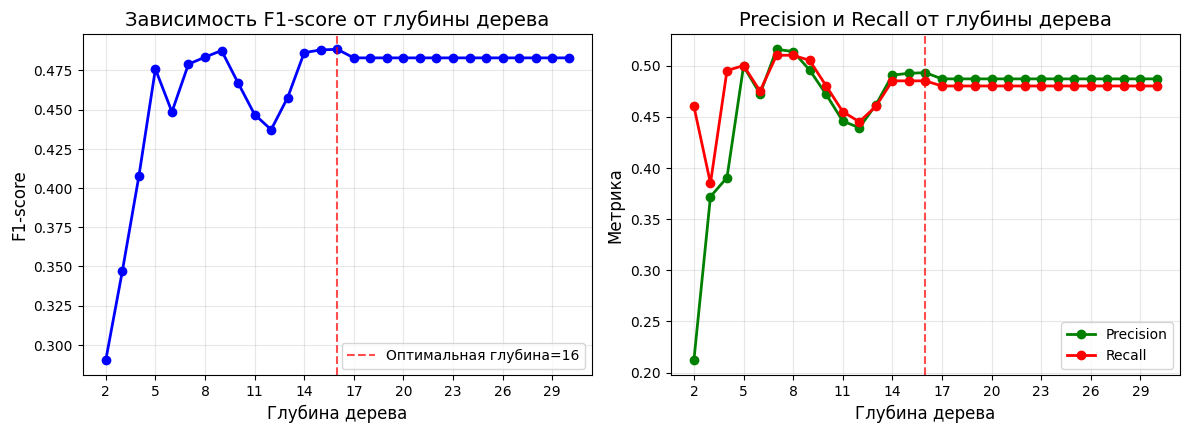

In [64]:
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(range(2, 31), f1_scores_tree, 'b-o', linewidth=2, markersize=6)
plt.axvline(x=best_depth, color='r', linestyle='--', alpha=0.7, label=f'Оптимальная глубина={best_depth}')
plt.xlabel('Глубина дерева', fontsize=12)
plt.ylabel('F1-score', fontsize=12)
plt.title('Зависимость F1-score от глубины дерева', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.xticks(range(2, 31, 3))

plt.subplot(2, 2, 2)
plt.plot(range(2, 31), precision_scores_tree, 'g-o', label='Precision', linewidth=2, markersize=6)
plt.plot(range(2, 31), recall_scores_tree, 'r-o', label='Recall', linewidth=2, markersize=6)
plt.axvline(x=best_depth, color='r', linestyle='--', alpha=0.7)
plt.xlabel('Глубина дерева', fontsize=12)
plt.ylabel('Метрика', fontsize=12)
plt.title('Precision и Recall от глубины дерева', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.xticks(range(2, 31, 3))

plt.tight_layout()
plt.show()

Видим значительное улучшение модели дерева решений. При глубине 16 F-мера достигает 0.487, Precision составляет 0.55, Recall - 0.53.
На основе модели нельзя делать предсказания, ведь ее выводы примерно равны случайным угадываниям.

